In [82]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot
import torch
from torch import nn, optim
import pathlib
import os
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#https://link.springer.com/content/pdf/10.1007/978-981-96-7005-5.pdf
# https://www.youtube.com/watch?v=qiUEgSCyY5o

In [83]:
## _-------------------------- Inladen van de data uit de data bestanden

def loader_to_tensor(loader):
    all_data = []
    for batch in loader:
        # batch is a tuple (features,) because no labels
        all_data.append(batch[0])
    return torch.cat(all_data, dim=0)

# Get the data of the simulated outliers.
with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    tree = file['treeMLDplus']
    branches = tree.keys()
    training_data_FD = tree.arrays(branches, library="np")
    labeled_anomaly_data_tensor = torch.tensor(pd.DataFrame(training_data_FD).values)

# Get the unlabeled data. Since this data file is very large and we do not use all of it for training, limit to 10.000 datapoints for now
with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file_test:
    tree_test = file_test['treeMLDplus']
    branches_test = tree_test.keys()
    training_data_bkg = tree_test.arrays(branches_test, library="np")
    training_data_bkg_df = pd.DataFrame(training_data_bkg)[0:100000]
    print(len(training_data_bkg_df))
    unlabeled_data_tensor = torch.tensor(training_data_bkg_df.values)


100000


In [84]:
from torch.utils.data import ConcatDataset
# Normalize each feature, according to the type of distribution it seems to follow to optimise performance

#! TODO explain the differences in transformation methods, and why different methods do and do not work here
# de quantiletransformer kan niet worden gefit op de trainingsdata bijvoorbeeld en dan gebruikt op beide, omdat die data buiten bereik van trainingsdata clipt.

import torch
from sklearn.preprocessing import PowerTransformer
from torch.utils.data import TensorDataset, DataLoader

# Normalize both datasets
qt = QuantileTransformer(
    n_quantiles=1000,
    output_distribution='normal',
    random_state=0,
    copy=True
)
qt.fit(labeled_anomaly_data_tensor)

labeled_norm = qt.transform(labeled_anomaly_data_tensor).astype(np.float32)
unlabeled_norm = qt.transform(unlabeled_data_tensor).astype(np.float32)

# Create labels
# Signal = labeled anomalies
signal_tensor = torch.tensor(labeled_norm[:, 1:], dtype=torch.float32)  # drop invariant mass
signal_inv_mass = torch.tensor(labeled_norm[: , 0], dtype=torch.float32)
signal_labels = torch.ones(signal_tensor.shape[0], dtype=torch.float32)

# Background = unlabeled points outside ±3σ of invariant mass
unlabeled_inv_mass = torch.tensor(unlabeled_norm[:, 0])
background_mask = (unlabeled_inv_mass < -3) | (unlabeled_inv_mass > 3)
background_tensor = torch.tensor(unlabeled_norm[background_mask, 1:], dtype=torch.float32)  # drop inv mass
background_inv_mass = torch.tensor(unlabeled_norm[background_mask,0],dtype=torch.float32)
background_labels = torch.zeros(background_tensor.shape[0], dtype=torch.float32)

# Define the weight of both sets, according to their length
pos_weight = labeled_anomaly_data_tensor.shape[0] / unlabeled_data_tensor.shape[0]

# Combine into one dataset

all_features = torch.cat([signal_tensor, background_tensor], dim=0)
all_labels = torch.cat([signal_labels, background_labels], dim=0)
all_inv_mass = torch.cat([signal_inv_mass,background_inv_mass], dim=0)
dataset = TensorDataset(all_features, all_labels, all_inv_mass) # Load separately the labels, features and invariant mass into the dataset object
background_dataset = TensorDataset(torch.tensor(unlabeled_norm,dtype=torch.float32))
# Single DataLoader
loader = DataLoader(dataset, batch_size=2000, shuffle=True)
loader_background = DataLoader(background_dataset, batch_size=2000, shuffle=True)


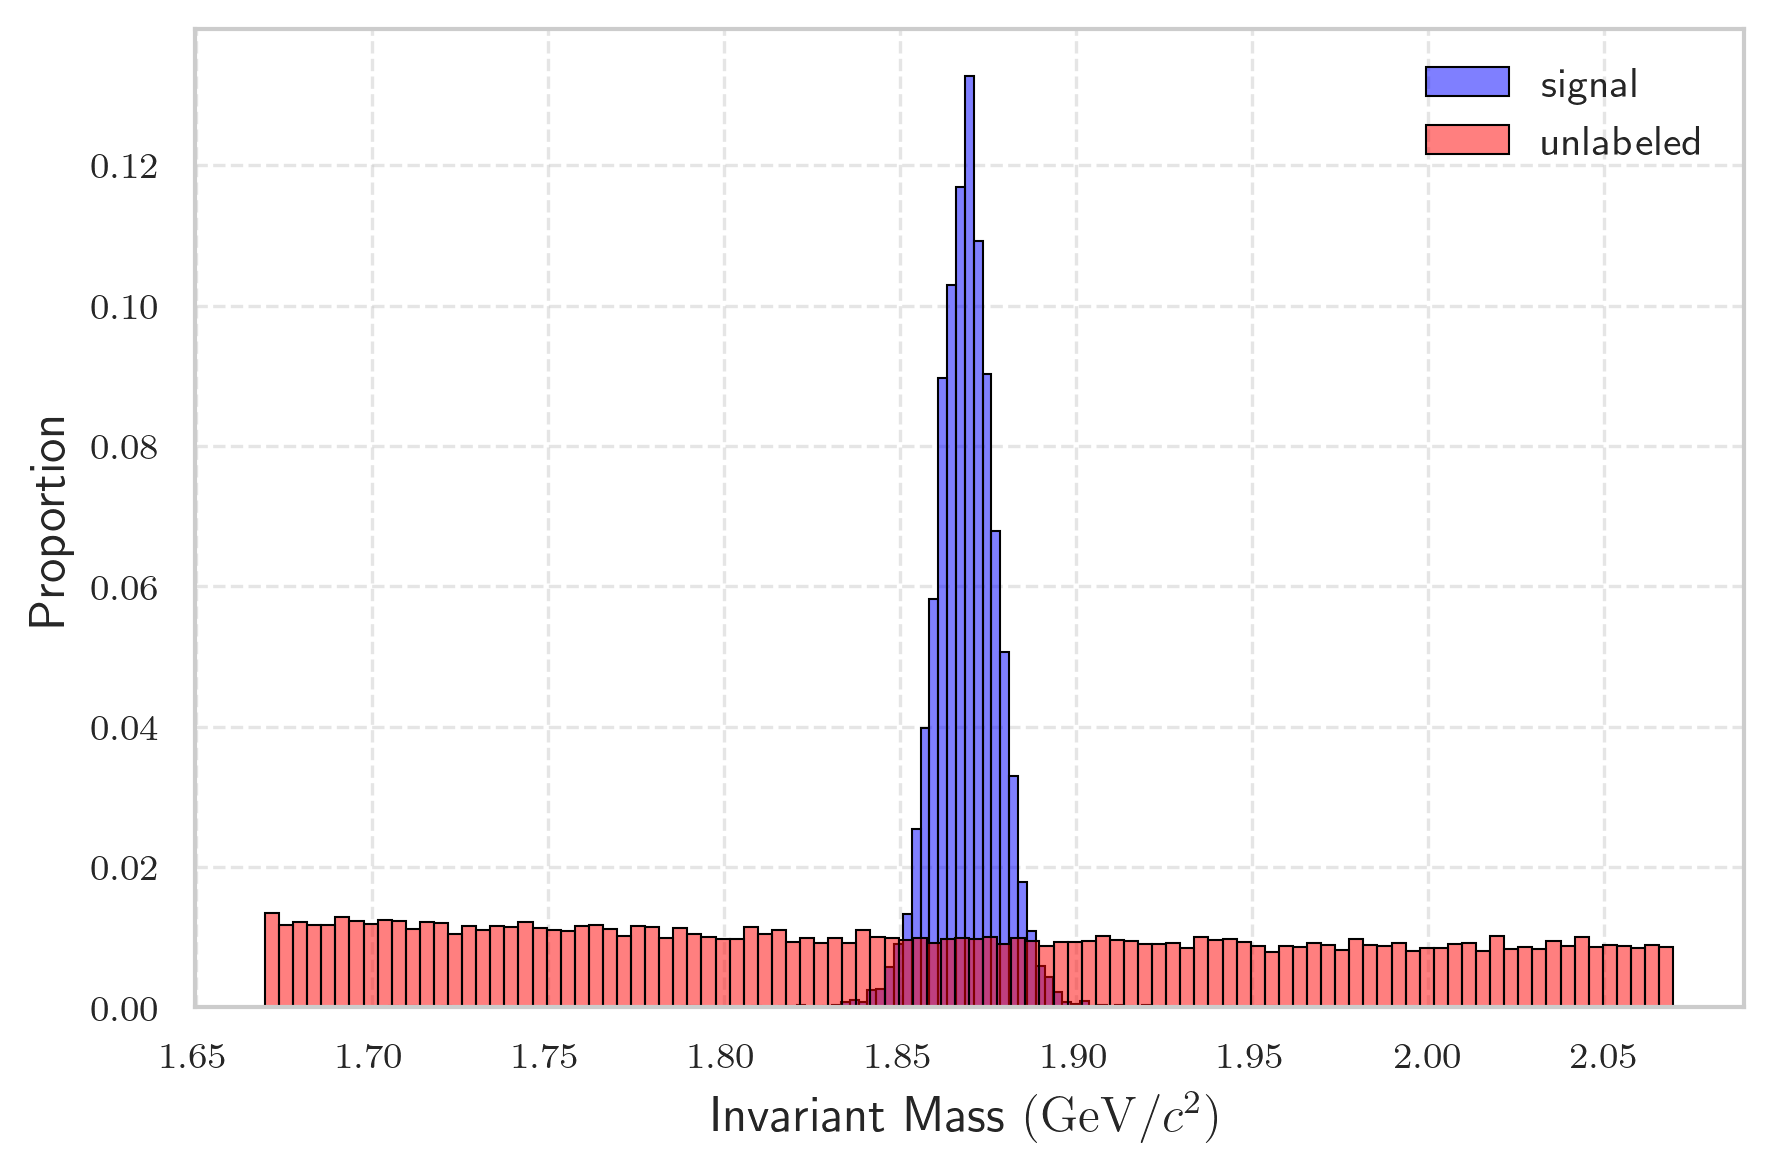

In [85]:
plt.figure(figsize=(6,4), dpi=300)  # adjust figure size for paper
sns.set_style("whitegrid")  # white background with light grid
sns.set_context("paper")    # smaller fonts for publication

for i, col in enumerate(branches):
    if col == 'inv_mass': 
        # Signal
        sns.histplot(
            labeled_anomaly_data_tensor[:, i], 
            bins=100, 
            color='blue', 
            alpha=0.5, 
            label='signal',
            stat='proportion',
            edgecolor='black',   # optional: edges for clarity
            linewidth=0.5
        )
        # Unlabeled
        sns.histplot(
            unlabeled_data_tensor[:, i], 
            bins=100, 
            color='red', 
            alpha=0.5, 
            label='unlabeled',
            stat='proportion',
            edgecolor='black',
            linewidth=0.5
        )

plt.xlabel(r'Invariant Mass $(\mathrm{GeV}/c^2)$', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.legend(frameon=False, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)  # subtle dashed grid
plt.tight_layout()
plt.show()


In [86]:
from torch.utils.data import random_split, DataLoader, TensorDataset
import torch

# -------------------------------
# Split into train and test
# -------------------------------
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

# -------------------------------
# Create DataLoaders
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=2000, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2000, shuffle=False)


In [87]:
# Definieer een neuraal netwerk om te classificeren
import torch
import torch.nn as nn

class AnomalyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.classifier = nn.Sequential(
            nn.Linear(15, 64),
            nn.BatchNorm1d(64),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.classifier(x)



In [91]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

def model_train(model, train_loader, test_loader, n_epochs=100, lr=1e-4):
    """
    Train a PyTorch model on a training DataLoader and validate on test_loader.
    Uses BCE loss for binary classification.
    """
    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device)
    )
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    loss_array = []
    best_acc = -float('inf')
    best_weights = None

    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(train_loader, unit="batch", mininterval=0, disable=False) as bar:
            bar.set_description(f"Epoch {epoch}")
            for X_batch, y_batch, inv_mass in bar:
                y_batch = y_batch.unsqueeze(1)  # ensure shape (batch_size, 1)
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                acc = (y_pred.round() == y_batch).float().mean()
                bar.set_postfix(loss=float(loss), acc=float(acc))

        # Evaluate on test_loader
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_val, y_val, inv_mass in test_loader:
                y_val = y_val.unsqueeze(1)
                y_val_pred = model(X_val)
                correct += (y_val_pred.round() == y_val).sum().item()
                total += y_val.size(0)

        acc = correct / total
        loss_array.append(loss)
        if acc > best_acc:
            best_acc = acc
            best_weights = copy.deepcopy(model.state_dict())

    # Restore best weights
    model.load_state_dict(best_weights)
    return best_acc, torch.stack(loss_array, dim=0).detach().numpy()


Epoch 99: 100%|██████████| 34/34 [00:02<00:00, 16.69batch/s, acc=0.942, loss=0.659]


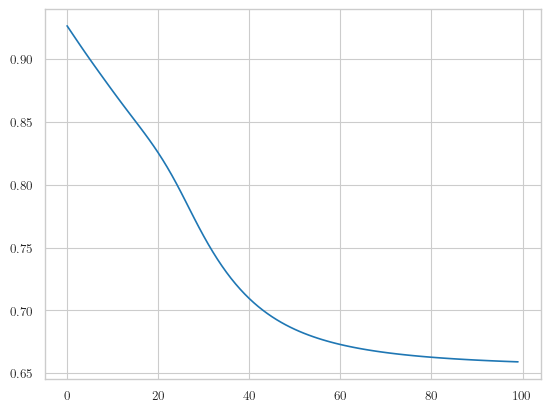

In [92]:
model = AnomalyMLP()
acc, loss_array = model_train(model,train_loader,test_loader)

plt.figure()
plt.plot(loss_array)
plt.show()

Best threshold: 0.4600
Best F1 score: 0.7195
<class 'numpy.ndarray'>
[[76356  1591]
 [ 1635  4137]]


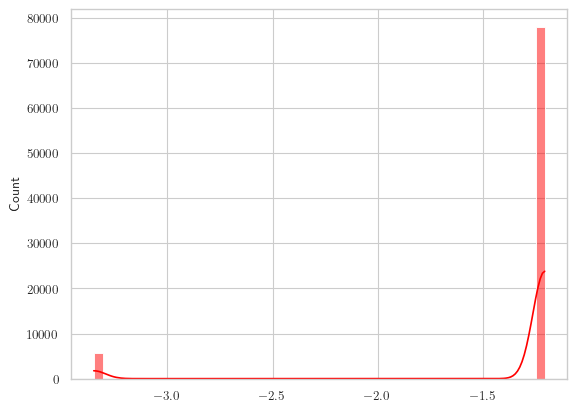

In [100]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Ensure the model is in eval mode
model.eval()

outlier_scores = []
y_true = []
inv_mass_total = []
with torch.no_grad():
    for X_batch, y_batch, inv_mass in loader:
        y_pred = model(X_batch)

        outlier_scores.append(y_pred.detach().cpu())
        y_true.append(y_batch.detach().cpu())
        inv_mass_total.append(inv_mass)

y_scores = torch.cat(outlier_scores).numpy().ravel()
y_true = torch.cat(y_true).numpy().ravel()
inv_mass_total = torch.cat(inv_mass_total).numpy().ravel()
        
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_labels = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, y_pred_labels))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1 score: {best_f1:.4f}")

y_pred_final = (y_scores >= best_threshold).astype(int)
print(type(y_pred_final))
inv_mass_candidates = inv_mass_total[y_pred_final]

cm = confusion_matrix(y_true, y_pred_final)
print(cm)

# # Concatenate all scores
# # Concatenate all predictions for the full dataset
# outlier_scores = torch.cat(outlier_scores, dim=0).squeeze()  # shape: (N_total,)
# X_all = torch.cat(X_all, dim = 0).squeeze()
# # Create a mask on the full background tensor
# threshold = 0.95
# outlier_mask = outlier_scores > threshold

# # Apply mask to full background features (exclude invariant mass)
plt.figure()
sns.histplot(inv_mass_candidates, bins=50, color='red', alpha=0.5, label='outlier', kde=True)
plt.show()

C:\Users\sande\AppData\Local\Temp\ipykernel_26188\2890929507.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  param, param_cov = curve_fit(exponential,bins_masked,hist_masked)


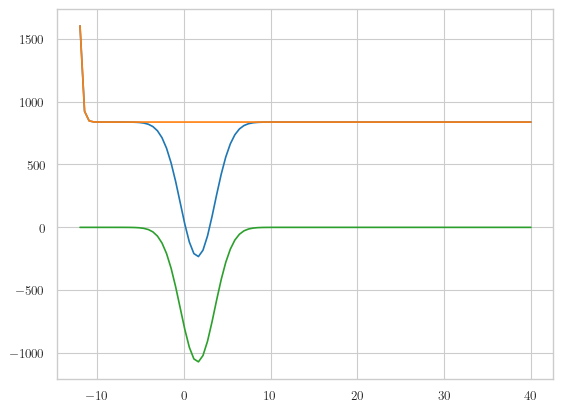

([array([764.88973532,  64.45771658,   1.        , 837.18991426]),
  array([-1070.54396538,     1.55883637,    -1.97821953])],
 [array([[inf, inf, inf, inf],
         [inf, inf, inf, inf],
         [inf, inf, inf, inf],
         [inf, inf, inf, inf]]),
  array([[ 2.49616906e+06,  2.11914608e+02, -3.40073117e+03],
         [ 2.11914608e+02,  1.15857283e+01, -1.06584852e+00],
         [-3.40073117e+03, -1.06584852e+00,  1.31150956e+01]])])

In [99]:
import numpy as np
from scipy.optimize import curve_fit
# Define the different functions we want to fit.
def exponential(x, a, b,c,d):
        # Standard exponential function, shifted to the left to help fitting
        return a*b**(-x-c-11)+d 

def gaussian(x,a,b,c):
    return a*np.exp(-(x-b)**2/(2*c**2))

def bump_hunt(candidates,bins=101):
    # Fit an exponential on the data first, then a gaussian.

    # Histogram the data
    hist,bins = np.histogram(candidates,bins=100)
    bins = bins[0:-1]
    mask = (bins < -5) & (bins > 5) # Exclude area of interest
    hist_masked, bins_masked = hist[~mask],bins[~mask]

    # Fit exponential outside signal area.
    param, param_cov = curve_fit(exponential,bins_masked,hist_masked)

    def bump_gaussian(x, a, b, c):
        # Combination of exponential and guassian. 
        # If exponential_params= False return just the gaussian. 
        # If the parameters of the exponential are passed, return the combination.
        return exponential(x, *param) + a*np.exp(-(x-b)**2/(2*c**2))

    param_2, param_cov_2 = curve_fit(bump_gaussian, bins,hist)

    # plot it
    x = np.linspace(-12,40, num=100)
    plt.figure()
    plt.plot(x,bump_gaussian(x,*param_2))
    plt.plot(x,exponential(x,*param))
    plt.plot(x,gaussian(x,*param_2))
    plt.show()

    # return a list of parameters and covariances
    return [param, param_2], [param_cov, param_cov_2]

# Hunt the distribution of candidates for a bump
bump_hunt(inv_mass_candidates)